# Импорты

In [ ]:
# system & utilities
import os
import gzip
import time
import pickle
import pytz
import warnings
warnings.filterwarnings('ignore')

# data analysis and wrangling
import math
import numpy as np
import pandas as pd
import datetime as dt
import random as rnd
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from typing import Dict, List, Optional

# database & integrations
from clickhouse_driver import Client
import gspread
from gspread_dataframe import set_with_dataframe
from oauth2client.service_account import ServiceAccountCredentials
from google.oauth2.service_account import Credentials

# reporting & notifications
from slack_sdk import WebClient
from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font
from openpyxl.utils import get_column_letter

# visualization & display
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
from itables import init_notebook_mode, show

# notebook settings
%matplotlib inline
init_notebook_mode(all_interactive=True)    
pd.set_option('display.float_format', '{:.2f}'.format)

# machine learning
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, QuantileTransformer

from sklearn.model_selection import cross_val_score, StratifiedKFold

from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

from sklearn.metrics import mean_squared_error, root_mean_squared_error


engine = Client(host='data-dep.owdp.tech',
                user='artem_aksenov',
                password='Nb+SESHO/m1FFr5',
                secure=True,
    )

# EDA

In [85]:
gender_submission = pd.read_csv(r'C:\jupyter\kaggle\titanik\gender_submission.csv')
train = pd.read_csv(r'C:\jupyter\kaggle\titanik\train.csv')
test = pd.read_csv(r'C:\jupyter\kaggle\titanik\test.csv')

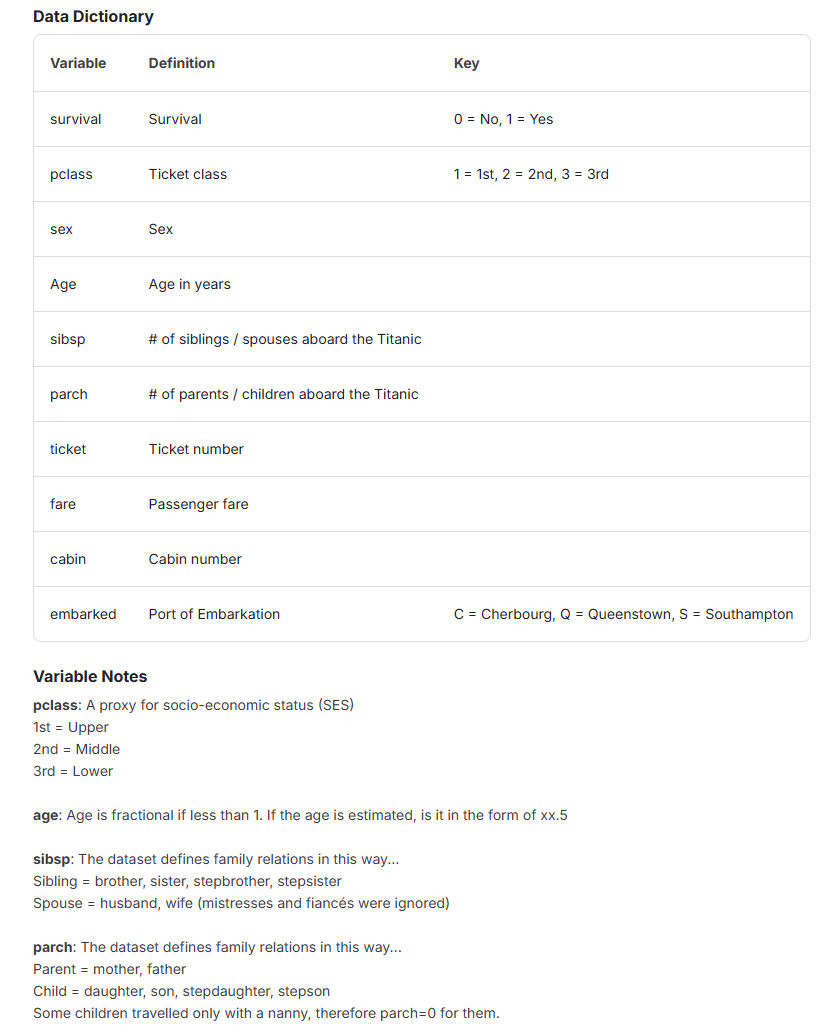

In [ ]:
train = train[['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Survived']]

df = test.merge(gender_submission, on='PassengerId', how='inner')

dataframe = pd.concat([train, df], axis=0, ignore_index=True)
dataframe

In [111]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   object 
 3   Sex          1309 non-null   object 
 4   Age          1046 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   object 
 8   Fare         1308 non-null   float64
 9   Cabin        295 non-null    object 
 10  Embarked     1307 non-null   object 
 11  Survived     1309 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


In [110]:
dataframe.describe()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [ ]:
missing_count = dataframe.isna().sum()
print(missing_count)

PassengerId       0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
Survived          0
dtype: int64


Возраст имеет пропуски, их можно заполнить медианой или средним, столбец Cabin стоит дропнуть, т.к. слишком много пропущенных значений, хотя возможно его можно дополнительно изучить или найти информацию, чтобы его заполнить, так как расположение кабин вероятно повлияет на то, что люди могли раньше добежать до шлюпок.

In [113]:
corr_matrix = dataframe.corr(numeric_only=True)
corr_matrix

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


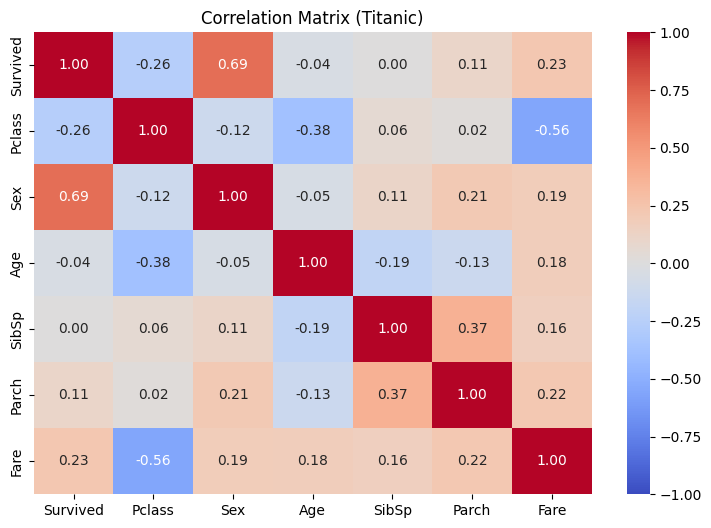

In [147]:
# Создаем копию и кодируем пол (female -> 1, male -> 0)
df_corr = dataframe.copy()
if "Sex" in df_corr.columns and df_corr["Sex"].dtype == "object":
    df_corr["Sex"] = df_corr["Sex"].map({"female": 1, "male": 0})

# Исключаем технический идентификатор PassengerId
cols_to_corr = [
    col
    for col in [
        "Survived",
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
    ]
    if col in df_corr.columns
]

# Расчет матрицы
corr_matrix = df_corr[cols_to_corr].corr()

# Отрисовка
plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Titanic)")
plt.show()

1) По матрице корреляций видно, что на выживаемость в первую очередь влияет пол и класс билета
2) По классу: на него влияет возраст и плата за билет, причем обратно пропорционально, ну потому что 1 класс стоит дороже, а третий дешевле, то есть корреляция обратная
3) По возрасту: как будто есть корреляция, чем выше возраст тем больше членов семьи на борту

In [130]:
survived = dataframe.groupby(['Sex', 'Pclass'], as_index=False).agg(

    survived_count=('Survived', 'sum'),
    total_count=('Survived', 'count'),

    ).sort_values(['Sex', 'Pclass'], ascending=[True, True])

survived['chance_sur'] = round(survived['survived_count'] / survived['total_count'], 2)

survived

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


женщин выжило намного больше, чем мужчин

In [132]:
survived = dataframe.groupby(['Sex', 'Embarked'], as_index=False).agg(

    survived_count=('Survived', 'sum'),
    total_count=('Survived', 'count'),

    ).sort_values(['Sex', 'Embarked'], ascending=[True, True])

survived['chance_sur'] = round(survived['survived_count'] / survived['total_count'], 2)

survived

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


видим что мужчин из порта C выжило больше

Вывод:

Выкинуть столбцы: 
1) Ticket(потому что практически уникальные значения), 
2) Cabin(много пропусков, НО возможно если дополнительно их заполнить реальной инфой, то это местоположение может дать доп очки), 
3) Fare(цена билет по сути отображена в колонке Pclass, опять же потенциально можно преобразовать в доп переменную либо понадеятся что этот столбец дополнительно потом еще даст большее значение метрики)
4) Name (логически это вообще ни на что влиять не может, но опять же как доп фича преобразованная может дать еще прирост метрики)

Преобразовать: Parch, SibSp (логика в том, что как будто если у людей больше детей/родственников, то они могли забить место в шлюпке)

Оставить: 
1) Sex (тут сильная корреляция, по статистике их выжило больше), 
2) Pclass (по статистике выжило больше пассажиров 1 и 2 класса), 
3) Age (возможно если преобразовать в категориальный признак, то окажется что выжившие мужчины - дети/подростки), 
4) Embarked (по статистике частично повлияло на выживаемость)



# Обработка + создание доп фичей

In [2]:
gender_submission = pd.read_csv(r'C:\jupyter\kaggle\titanik\gender_submission.csv')
train = pd.read_csv(r'C:\jupyter\kaggle\titanik\train.csv')
test = pd.read_csv(r'C:\jupyter\kaggle\titanik\test.csv')

test = test.merge(gender_submission, on='PassengerId', how='inner')

In [3]:
def preprocess_titanic(
    df: pd.DataFrame, scaler: StandardScaler = None, is_train: bool = True
) -> tuple[pd.DataFrame, StandardScaler]:
    # 1. Копирование и заполнение пропусков
    data = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']].copy()
    data['Age'] = data['Age'].fillna(data['Age'].median()).astype(int)

    # 2. Маппинг категорий
    data['Sex'] = data['Sex'].map({'female': 1, 'male': 0})
    data['Pclass'] = data['Pclass'].map({1: 'Upper', 2: 'Middle', 3: 'Lower'})
    data['Embarked'] = data['Embarked'].map(
        {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
    )

    # 3. Признаки семьи и возраста
    data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
    data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

    bins = [0, 12, 18, 35, 60, 100]
    data['AgeGroup'] = pd.cut(data['Age'], bins=bins, labels=False, right=False)

    # 4. One-Hot Encoding
    features = [
        'Pclass',
        'Sex',
        'Parch',
        'Embarked',
        'FamilySize',
        'IsAlone',
        'AgeGroup',
    ]
    X = pd.get_dummies(data[features], dtype=int, drop_first=True)

    # 5. Масштабирование возраста (Age)
    if is_train:
        scaler = StandardScaler()
        X['Age_scaled'] = scaler.fit_transform(data[['Age']])
    else:
        X['Age_scaled'] = scaler.transform(data[['Age']])

    X['Age'] = data['Age']

    return X, scaler

In [4]:
X_train, scaler = preprocess_titanic(train[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']], is_train=True)

X_test, _ = preprocess_titanic(test, scaler=scaler, is_train=False)

Y_train = train["Survived"]

Y_test = test['Survived']

In [5]:
# 1. Логистическая регрессия
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, Y_train)

# 2. CatBoost
catboost_model = CatBoostClassifier(
    iterations=500, random_seed=42, verbose=100
)
catboost_model.fit(X_train, Y_train)

Learning rate set to 0.018517
0:	learn: 0.6843130	total: 144ms	remaining: 1m 11s
100:	learn: 0.3916078	total: 231ms	remaining: 914ms
200:	learn: 0.3627484	total: 315ms	remaining: 468ms
300:	learn: 0.3471301	total: 396ms	remaining: 262ms
400:	learn: 0.3317524	total: 477ms	remaining: 118ms
499:	learn: 0.3164303	total: 559ms	remaining: 0us


CatBoostClassifier(iterations=500, random_seed=42, verbose=100)

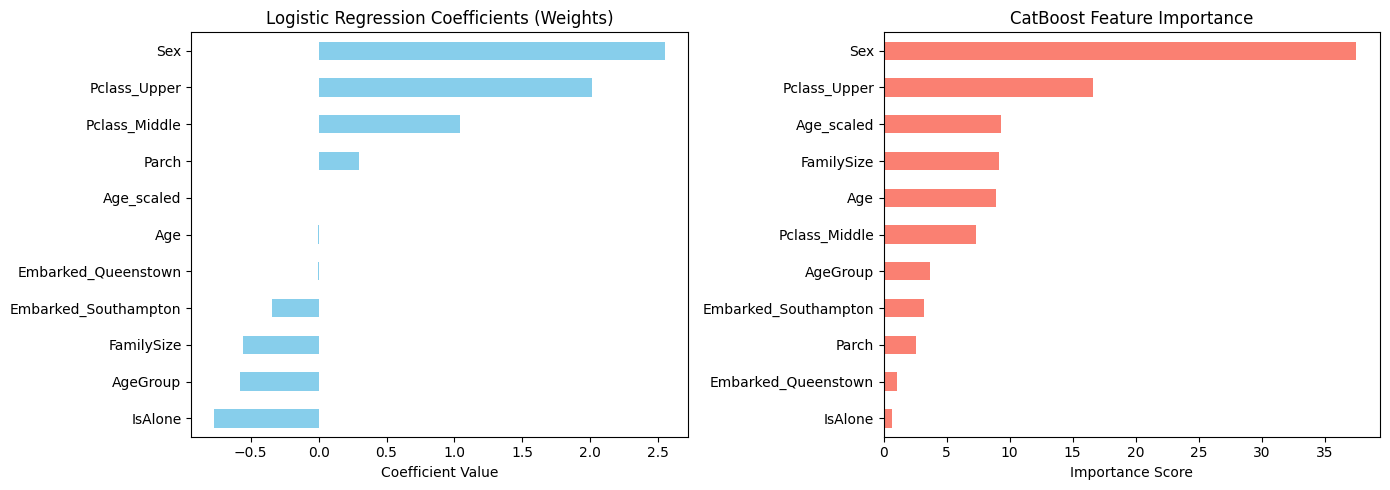

In [6]:
# Получаем важности признаков
lr_importance = pd.Series(
    log_reg.coef_[0], index=X_train.columns
).sort_values()
cb_importance = pd.Series(
    catboost_model.get_feature_importance(), index=X_train.columns
).sort_values()

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Коэффициенты Logistic Regression
lr_importance.plot(kind="barh", ax=axes[0], color="skyblue")
axes[0].set_title("Logistic Regression Coefficients (Weights)")
axes[0].set_xlabel("Coefficient Value")

# График 2: Feature Importance CatBoost
cb_importance.plot(kind="barh", ax=axes[1], color="salmon")
axes[1].set_title("CatBoost Feature Importance")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

# Модели

In [ ]:
from ml_pipeline import TuningConfig, PipelineConfig, MLPipeline

# 1. Настройка тюнинга Optuna для всех 5 моделей классификации
tuning_cfg = TuningConfig(
    search_engine="optuna",
    n_trials=30,  # Можно увеличить (например, до 20-30) для более точного поиска
    param_spaces={

        "lgb": {
            
        "n_estimators": (50, 300),
        "learning_rate": (0.001, 0.1),
        "num_leaves": (15, 63),
        "max_depth": (3, 10),
        "subsample": (0.6, 1.0),
        "colsample_bytree": (0.6, 1.0),
        "reg_alpha": (1e-3, 10.0),
        "reg_lambda": (1e-3, 10.0),
        "min_child_samples": (10, 100),

        }, "xgb": {

        "n_estimators": (50, 300),
        "learning_rate": (0.001, 0.1),
        "max_depth": (3, 10),
        "subsample": (0.6, 1.0),
        "colsample_bytree": (0.6, 1.0),
        "gamma": (1e-8, 1.0),
        "reg_alpha": (1e-3, 10.0),
        "reg_lambda": (1e-3, 10.0),
        "min_child_weight": (1, 10),

        }, "cat": {

        "iterations": (100, 400),
        "learning_rate": (0.001, 0.1),
        "depth": (4, 8),
        "l2_leaf_reg": (1.0, 10.0),
        "subsample": (0.6, 1.0),
        "random_strength": (1e-3, 10.0),

        }, "rf": {

        "n_estimators": (50, 200),
        "max_depth": (3, 12),
        "min_samples_split": (2, 20),
        "min_samples_leaf": (1, 10),
        "max_features": (0.5, 1.0),
        "bootstrap": [True, False],

        }, "logreg": {

        "C": (0.001, 10.0),
        }
    }
)

# 2. Главная конфигурация — добавляем все модели в active_models
config = PipelineConfig(
    task="binary",
    val_strategy="stratified",
    n_splits=5,
    metric="roc_auc",
    run_mode="tune",
    tuning_config=tuning_cfg,
    active_models=["logreg", "rf", "lgb", "xgb", "cat"]
)

# 3. Инициализация пайплайна
pipeline = MLPipeline(config=config)

# 4. Обучение и поиск гиперпараметров
scores = pipeline.fit(X=X_train, y=Y_train)

# 5. Инференс на тестовой выборке
sub_preds = pipeline.predict(X_test=X_test)

# Вывод результатов (в ensemble_pred теперь усреднение всех 5 моделей)
sub_preds.head()

[Tuner] Старт подбора для 'logreg' (30 итераций)...
[Tuner] Лучшие параметры для logreg: {'C': 4.685302988361172}
[Tuner] Старт подбора для 'rf' (30 итераций)...
[Tuner] Лучшие параметры для rf: {'n_estimators': 106, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 0.8839358319803665, 'bootstrap': True}
[Tuner] Старт подбора для 'lgb' (30 итераций)...
[Tuner] Лучшие параметры для lgb: {'n_estimators': 98, 'learning_rate': 0.0752725037658935, 'num_leaves': 23, 'max_depth': 9, 'subsample': 0.816044908254842, 'colsample_bytree': 0.8309261503899917, 'reg_alpha': 0.07346857083905012, 'reg_lambda': 2.2984435831408896, 'min_child_samples': 29}
[Tuner] Старт подбора для 'xgb' (30 итераций)...
[Tuner] Лучшие параметры для xgb: {'n_estimators': 204, 'learning_rate': 0.04452146912998373, 'max_depth': 8, 'subsample': 0.7585736290152091, 'colsample_bytree': 0.7763197198391156, 'gamma': 0.4591292285410246, 'reg_alpha': 1.8432166254765274, 'reg_lambda': 2.200217590506706

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [9]:
from ml_pipeline import TuningConfig, PipelineConfig, MLPipeline

# 1. Настройка тюнинга Optuna для всех 5 моделей классификации
tuning_cfg = TuningConfig(
    search_engine="optuna",
    n_trials=30,  # Можно увеличить (например, до 20-30) для более точного поиска
    param_spaces={

        "lgb": {
            
        "n_estimators": (50, 300),
        "learning_rate": (0.001, 0.1),
        "num_leaves": (15, 63),
        "max_depth": (3, 10),
        "subsample": (0.6, 1.0),
        "colsample_bytree": (0.6, 1.0),
        "reg_alpha": (1e-3, 10.0),
        "reg_lambda": (1e-3, 10.0),
        "min_child_samples": (10, 100),

        }, "xgb": {

        "n_estimators": (50, 300),
        "learning_rate": (0.001, 0.1),
        "max_depth": (3, 10),
        "subsample": (0.6, 1.0),
        "colsample_bytree": (0.6, 1.0),
        "gamma": (1e-8, 1.0),
        "reg_alpha": (1e-3, 10.0),
        "reg_lambda": (1e-3, 10.0),
        "min_child_weight": (1, 10),

        }, "cat": {

        "iterations": (100, 400),
        "learning_rate": (0.001, 0.1),
        "depth": (4, 8),
        "l2_leaf_reg": (1.0, 10.0),
        "subsample": (0.6, 1.0),
        "random_strength": (1e-3, 10.0),

        }, "rf": {

        "n_estimators": (50, 200),
        "max_depth": (3, 12),
        "min_samples_split": (2, 20),
        "min_samples_leaf": (1, 10),
        "max_features": (0.5, 1.0),
        "bootstrap": [True, False],

        }, "logreg": {

        "C": (0.001, 10.0),
        }
    }
)

# 2. Главная конфигурация — добавляем все модели в active_models
config = PipelineConfig(
    task="binary",
    val_strategy="stratified",
    n_splits=5,
    metric="accuracy",
    run_mode="tune",
    tuning_config=tuning_cfg,
    active_models=["logreg", "rf", "lgb", "xgb", "cat"]
)

# 3. Инициализация пайплайна
pipeline = MLPipeline(config=config)

# 4. Обучение и поиск гиперпараметров
scores = pipeline.fit(X=X_train, y=Y_train)

# 5. Инференс на тестовой выборке
sub_preds = pipeline.predict(X_test=X_test)

# Вывод результатов (в ensemble_pred теперь усреднение всех 5 моделей)
sub_preds.head()

[Tuner] Старт подбора для 'logreg' (30 итераций)...
[Tuner] Лучшие параметры для logreg: {'C': 0.8110851318175621}
[Tuner] Старт подбора для 'rf' (30 итераций)...
[Tuner] Лучшие параметры для rf: {'n_estimators': 122, 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 0.7306919133656935, 'bootstrap': False}
[Tuner] Старт подбора для 'lgb' (30 итераций)...
[Tuner] Лучшие параметры для lgb: {'n_estimators': 240, 'learning_rate': 0.01741056507077833, 'num_leaves': 33, 'max_depth': 3, 'subsample': 0.9008464375049143, 'colsample_bytree': 0.6335509775709923, 'reg_alpha': 0.976105046959049, 'reg_lambda': 1.5444766835682047, 'min_child_samples': 15}
[Tuner] Старт подбора для 'xgb' (30 итераций)...
[Tuner] Лучшие параметры для xgb: {'n_estimators': 96, 'learning_rate': 0.07260235065526043, 'max_depth': 5, 'subsample': 0.7894749120993296, 'colsample_bytree': 0.8135891440671253, 'gamma': 0.5290923564550779, 'reg_alpha': 0.6972644760905915, 'reg_lambda': 0.659707093707

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


# DL

In [20]:
%load_ext autoreload
%autoreload 2

import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score
from dl_pipeline import DLConfig, DLTrainer

# Преобразуем данные в numpy массивы, если они переданы как pandas DataFrame/Series
X_tr = X_train.values if hasattr(X_train, 'values') else X_train
Y_tr = Y_train.values if hasattr(Y_train, 'values') else Y_train
X_te = X_test.values if hasattr(X_test, 'values') else X_test
Y_te = Y_test.values if hasattr(Y_test, 'values') else Y_test

# 1. Конфигурация простой архитектуры: 2 линейных слоя + ReLU
cfg_simple = DLConfig(
    hidden_units=[64, 32],       # Двухслойный MLP
    activation='relu',           # Активация
    use_batchnorm=False,         # Без BatchNorm
    dropout_rates=0.0,           # Без Dropout
    optimizer_name='adam',       # Простой Adam
    lr=1e-3,
    batch_size=64,
    epochs=15,
    use_scheduler=False,         # Без планировщика LR
    task='binary'
)

# 2. Обучение модели
trainer_simple = DLTrainer(cfg_simple)
history_simple = trainer_simple.fit(X_tr, Y_tr, X_te, Y_te)

# 3. Инференс и расчет метрик качество на тесте
test_probs = trainer_simple.predict(X_te)
preds_binary = (test_probs > 0.5).astype(int)

print("\n--- Метрики качества (Simple MLP) ---")
print(f"Test Accuracy: {accuracy_score(Y_te, preds_binary):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(Y_te, test_probs):.4f}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Epoch 01/15 | Train Loss: 0.6786 | Val Loss: 0.6711 | LR: 0.001000
Epoch 02/15 | Train Loss: 0.6765 | Val Loss: 0.6562 | LR: 0.001000
Epoch 03/15 | Train Loss: 0.6597 | Val Loss: 0.6487 | LR: 0.001000
Epoch 04/15 | Train Loss: 0.6514 | Val Loss: 0.6382 | LR: 0.001000
Epoch 05/15 | Train Loss: 0.6432 | Val Loss: 0.6366 | LR: 0.001000
Epoch 06/15 | Train Loss: 0.6365 | Val Loss: 0.6153 | LR: 0.001000
Epoch 07/15 | Train Loss: 0.6268 | Val Loss: 0.6008 | LR: 0.001000
Epoch 08/15 | Train Loss: 0.6148 | Val Loss: 0.5833 | LR: 0.001000
Epoch 09/15 | Train Loss: 0.5968 | Val Loss: 0.5571 | LR: 0.001000
Epoch 10/15 | Train Loss: 0.5744 | Val Loss: 0.5224 | LR: 0.001000
Epoch 11/15 | Train Loss: 0.5463 | Val Loss: 0.4924 | LR: 0.001000
Epoch 12/15 | Train Loss: 0.5181 | Val Loss: 0.4488 | LR: 0.001000
Epoch 13/15 | Train Loss: 0.4932 | Val Loss: 0.4121 | LR: 0.001000
Epoch 14/15 | Train Loss: 0.4709 | Val Lo

In [19]:
# Настраиваем глубокую сеть с регуляризацией и сchedulers
cfg_advanced = DLConfig(
    hidden_units=[256, 128, 64, 32],       # Больше слоев разной ширины
    activation='gelu',                     # Попробуем GELU (или leaky_relu, elu, silu)
    use_batchnorm=True,                    # Добавляем BatchNorm
    dropout_rates=[0.3, 0.3, 0.2, 0.1],    # Dropout под каждый скрытый слой
    optimizer_name='adamw',                # AdamW с весовым затуханием
    weight_decay=1e-3,
    lr=2e-3,
    batch_size=128,                        # Увеличили размер батча
    epochs=25,
    use_scheduler=True,                    # Косинусовый scheduler
    scheduler_type='cosine',
    task='binary'
)

# Запуск обучения
trainer_adv = DLTrainer(cfg_advanced)
history_adv = trainer_adv.fit(X_tr, Y_tr, X_te, Y_te)

# Предсказание вероятностей и расчет метрики (например, Accuracy или ROC-AUC)
from sklearn.metrics import accuracy_score, roc_auc_score

probs_adv = trainer_adv.predict(X_te)
preds_binary = (probs_adv > 0.5).astype(int)

print(f"Test Accuracy: {accuracy_score(Y_te, preds_binary):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(Y_te, probs_adv):.4f}")

Epoch 01/25 | Train Loss: 0.6610 | Val Loss: 0.6709 | LR: 0.001992
Epoch 02/25 | Train Loss: 0.6287 | Val Loss: 0.6482 | LR: 0.001969
Epoch 03/25 | Train Loss: 0.5632 | Val Loss: 0.5579 | LR: 0.001930
Epoch 04/25 | Train Loss: 0.5220 | Val Loss: 0.4067 | LR: 0.001876
Epoch 05/25 | Train Loss: 0.4935 | Val Loss: 0.3273 | LR: 0.001809
Epoch 06/25 | Train Loss: 0.4737 | Val Loss: 0.2781 | LR: 0.001729
Epoch 07/25 | Train Loss: 0.4547 | Val Loss: 0.2654 | LR: 0.001637
Epoch 08/25 | Train Loss: 0.4558 | Val Loss: 0.2593 | LR: 0.001536
Epoch 09/25 | Train Loss: 0.4409 | Val Loss: 0.2864 | LR: 0.001426
Epoch 10/25 | Train Loss: 0.4295 | Val Loss: 0.2938 | LR: 0.001309
Epoch 11/25 | Train Loss: 0.4351 | Val Loss: 0.2983 | LR: 0.001187
Epoch 12/25 | Train Loss: 0.4168 | Val Loss: 0.2736 | LR: 0.001063
Epoch 13/25 | Train Loss: 0.4194 | Val Loss: 0.2658 | LR: 0.000937
Epoch 14/25 | Train Loss: 0.4137 | Val Loss: 0.2800 | LR: 0.000813
Epoch 15/25 | Train Loss: 0.4209 | Val Loss: 0.2856 | LR: 0.00